# BasicTask3

L96を2年分積分し、最初の1年分をスピンアップとして捨てる。後半1年分を6時間毎に保存し、これを真値とする。Metsenne Twister法などの性質の良い乱数生成プログラムを用いて分散１の正規分布乱数を生成する。その際、ヒストグラム等で意図した乱数が生成されている事を確認する。その上で、保存した6時間毎の真値に足しこんで、別に保存する。これを観測データとする。

In [1]:
# 各種メソッドの定義
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

## Lorenz96モデルの定義
def L96(x, F):
    """
    Lorenz96モデルの微分方程式を定義する関数
    x: 状態変数の配列
    F: 外部からの強制力
    """
    N = len(x)
    dxdt = np.zeros(N)
    for i in range(N):
        dxdt[i] = (x[(i + 1) % N] - x[i - 2]) * x[i - 1] - x[i] + F
    return dxdt
## オイラー法の実装
def euler_step(x, F, dt):
    """
    オイラー法による1ステップの時間積分
    x: 現在の状態変数の配列
    F: 外部からの強制力
    dt: 時間ステップ
    """
    dxdt = L96(x, F)
    return x + dxdt * dt
## 4次のルンゲクッタ法の実装
def rk4_step(x, F, dt):
    """
    4次のルンゲクッタ法による1ステップの時間積分
    x: 現在の状態変数の配列
    F: 外部からの強制力
    dt: 時間ステップ
    """
    k1 = L96(x, F) * dt
    k2 = L96(x + 0.5 * k1, F) * dt
    k3 = L96(x + 0.5 * k2, F) * dt
    k4 = L96(x + k3, F) * dt
    return x + (k1 + 2 * k2 + 2 * k3 + k4) / 6

## 2次のルンゲクッタ法の実装
def rk2_step(x, F, dt):
    """
    2次のルンゲクッタ法による1ステップの時間積分
    x: 現在の状態変数の配列
    F: 外部からの強制力
    dt: 時間ステップ
    """
    k1 = L96(x, F)
    k2 = L96(x + dt * k1, F)
    return x + (dt / 2) * (k1 + k2)

## 状態変数の配列のコンストラクタ
class StateArray:
    def __init__(self, N, F, dt, method='rk4'):
        """
        状態変数の配列を初期化するクラス
        N: 状態変数の数
        F: 外部からの強制力
        dt: 時間ステップ
        method: 使用する時間積分メソッド ('euler', 'rk2', 'rk4')
        """
        self.N = N
        self.F = F
        self.dt = dt
        self.method = method
        self.x = F * np.ones(N)  # 初期状態をFで初期化
        self.x[N // 2] *= 1.001  # 中央の値を少し変化させる

    def step(self):
        """
        1ステップの時間積分を実行するメソッド
        """
        if self.method == 'euler':
            self.x = euler_step(self.x, self.F, self.dt)
        elif self.method == 'rk2':
            self.x = rk2_step(self.x, self.F, self.dt)
        elif self.method == 'rk4':
            self.x = rk4_step(self.x, self.F, self.dt)
        else:
            raise ValueError("Unknown method: {}".format(self.method))

# 与えらえたNの個数に基づいて、変数j個×N個のガウシアンノイズをリストで返すメソッド
def generate_gaussian_noise(j=40, N=1000, mean=0.0, std=1.0):
    """
    N個のガウシアンノイズを生成する関数
    N: ノイズの個数
    mean: ノイズの平均値
    std: ノイズの標準偏差
    """
    np.random.seed(0)
    return [np.random.normal(mean, std, j) for _ in range(N)]

## 真値の作成

In [2]:
# コンストラクタの定義
state = StateArray(N=40, F=8.0, dt=0.05, method='rk4')

# ステップ幅dt=0.05において、1日を0.2ステップとした場合の365日分のステップ数
steps_per_day = 0.2 / state.dt
steps_per_year = 365 * steps_per_day

# 真値の作成、最初の1年分をスピンアップとして捨て、後半1年分を6時間毎(ステップ毎)に保存
true_states = np.zeros((int(steps_per_year), state.N))
for step in range(int(2 * steps_per_year)):
    state.step()
    if step >= steps_per_year:
        true_states[step - int(steps_per_year)] = state.x
# 真値の保存
np.save('true_states.npy', true_states)

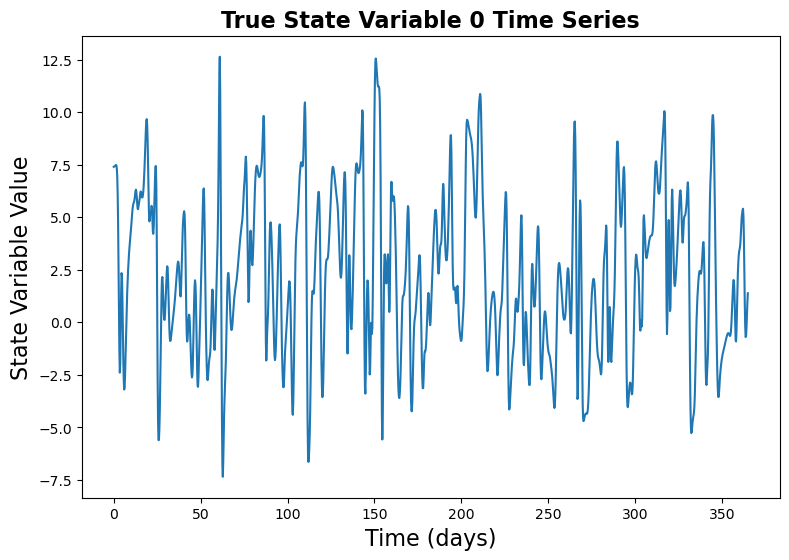

In [6]:
# true_states.npyの描画
true_states = np.load('true_states.npy')
plt.figure(figsize=(9, 6))
days = np.arange(true_states.shape[0]) / (0.2 / state.dt)
# true_statesのある変数の時系列を描画
plt.plot(days, true_states[:, 0], label='True State Variable 0')
plt.title('True State Variable 0 Time Series', fontsize=16, fontweight='bold')
plt.xlabel('Time (days)', fontsize=16)
plt.ylabel('State Variable Value', fontsize=16)
plt.show()

## 観測値の作成

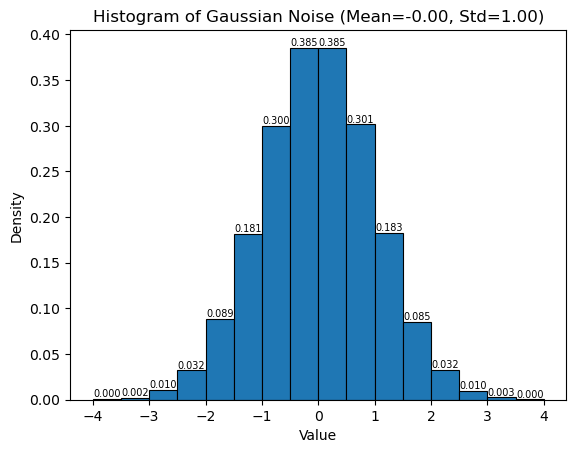

In [ ]:
# ガウシアンノイズの生成、分散1の正規分布乱数を生成
noise = np.array(generate_gaussian_noise(j=state.N, N=int(steps_per_year), mean=0.0, std=1.0))
# ヒストグラムをプロットして確認するため、一次元に平坦化
noise_flat = noise.ravel()
counts, bin_edges, patches = plt.hist(
    noise_flat,
    bins=16,
    density=True,
    histtype='bar',
    range=(-4, 4),
    edgecolor='black',
    linewidth=0.8
)
# 各ビンの上に密度を表示
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
for center, height in zip(bin_centers, counts):
    if height > 0:
        plt.text(center, height, f"{height:.3f}", ha='center', va='bottom', fontsize=7)
plt.title(f'Histogram of Gaussian Noise (Mean={np.mean(noise_flat):.2f}, Std={np.std(noise_flat):.2f})', fontsize=12)
plt.xlabel('Value')
plt.ylabel('Density')
plt.show()

In [4]:
# 真値を読み込み、ノイズを足しこんで観測値を作成
true_states = np.load('true_states.npy')
observed_states = true_states + noise
# 観測値の形状確認
print("Observed states shape:", observed_states.shape)
# 観測値の保存
np.save('observed_states.npy', observed_states)

Observed states shape: (1460, 40)
